
# Autoencoder

Autoencoder is a neural network trained to reconstruct its own input used for:
* Feature extraction
* Data compression
* Data generation
* Noise Reduction
* dimensionality Reduction(like PCA but nolinear)

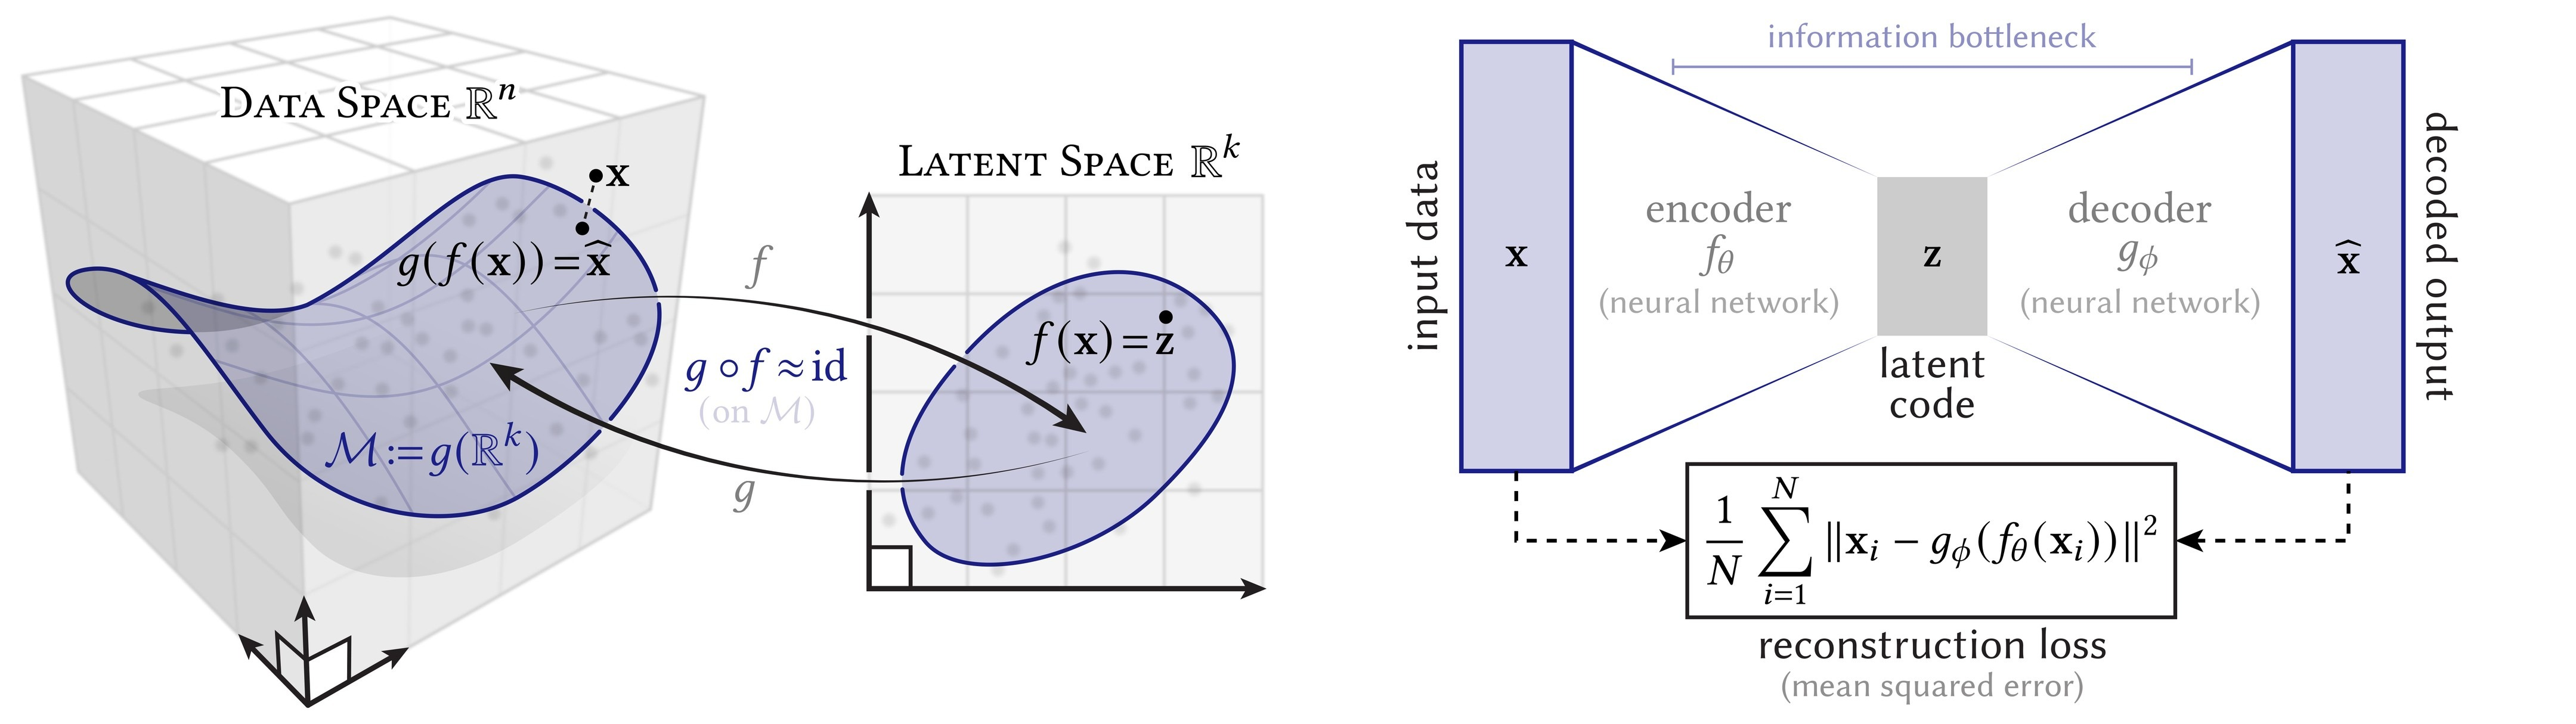

##Environment Setup

In [ ]:
!pip install torchinfo datasets torchvision

In [ ]:
import numpy as np
import random
import torch

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


##Dataset
We use MNIST — 70,000 handwritten digit images (0–9), each 28×28 pixels, grayscale.

* Training set: 51,000 samples
* Validation set: 9,000 samples
* Test set: 10,000 samples


In [ ]:
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split

transform = transforms.ToTensor()   # converts PIL image [0,255] → tensor [0,1]

# mnist dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dataset,val_dataset = train_test_split(train_dataset,test_size=0.15,random_state=42)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,download=True,transform=transform)

print(f"Train set size: {len(train_dataset)}")
print(f"Test  set size: {len(test_dataset)}")
print(f"Val  set size: {len(val_dataset)}")
print(f"Sample shape: {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.63MB/s]


Train set size: 51000
Test  set size: 10000
Val  set size: 9000
Sample shape: torch.Size([1, 28, 28])


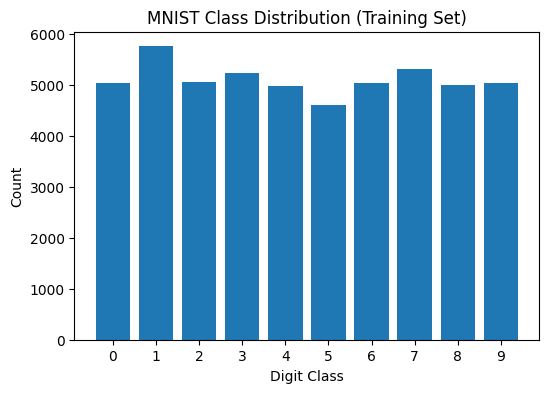

In [ ]:
from matplotlib import pyplot as plt

# ── Class distribution ─
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
counts = np.bincount(labels)

plt.figure(figsize=(6, 4))
plt.bar(range(10), counts)
plt.xticks(range(10))
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.title('MNIST Class Distribution (Training Set)')
plt.show()

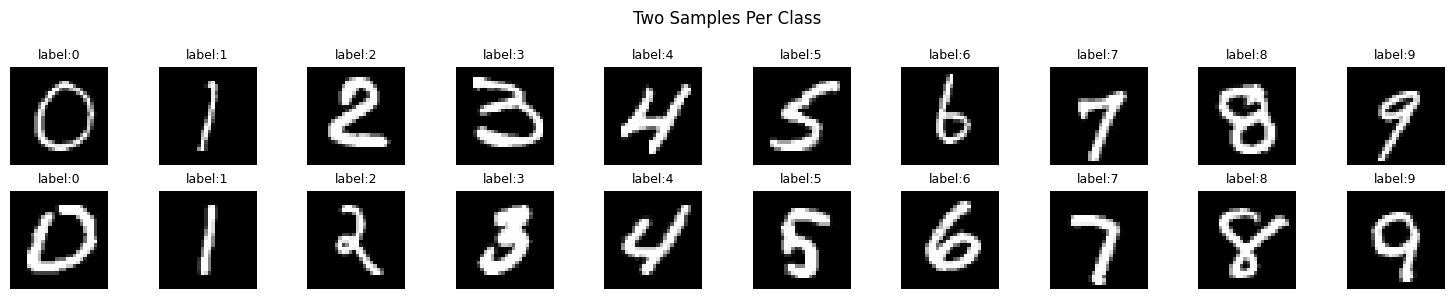

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
shown = {i: [] for i in range(10)}

for img, label in train_dataset:
    if len(shown[label]) < 2:
        shown[label].append(img.squeeze().numpy())
    if all(len(v) == 2 for v in shown.values()):
        break

for digit in range(10):
    for row in range(2):
        axes[row, digit].imshow(shown[digit][row], cmap='gray')
        axes[row, digit].set_title(f'label:{digit}', fontsize=9)
        axes[row, digit].axis('off')

plt.suptitle('Two Samples Per Class')
plt.tight_layout()
plt.show()

## 1: Convolutional Autoencoder
 Convolutional Autoencoders use Conv2d layers in the encoder and ConvTranspose2d (transposed convolution, a.k.a. deconvolution) in the decoder, preserving spatial relationships.

In [ ]:
import torch.nn as nn
from torchinfo import summary
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28→14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14→7
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

conv_ae = ConvAE().to(device)
summary(conv_ae, input_size=(4, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
ConvAE                                   [4, 1, 28, 28]            --
├─Sequential: 1-1                        [4, 32, 7, 7]             --
│    └─Conv2d: 2-1                       [4, 16, 14, 14]           160
│    └─ReLU: 2-2                         [4, 16, 14, 14]           --
│    └─Conv2d: 2-3                       [4, 32, 7, 7]             4,640
│    └─ReLU: 2-4                         [4, 32, 7, 7]             --
├─Sequential: 1-2                        [4, 1, 28, 28]            --
│    └─ConvTranspose2d: 2-5              [4, 16, 14, 14]           4,624
│    └─ReLU: 2-6                         [4, 16, 14, 14]           --
│    └─ConvTranspose2d: 2-7              [4, 1, 28, 28]            145
│    └─Sigmoid: 2-8                      [4, 1, 28, 28]            --
Total params: 9,569
Trainable params: 9,569
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 5.11
Input size (MB): 0.01
Forward/backward 

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20,lr=1e-3, noise_fn=None, sparse=False):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()

            inp = noise_fn(imgs) if noise_fn else imgs   # corrupt if DAE

            xhat, z = model(inp)
            loss = criterion(xhat, imgs)  # reconstruction loss

            if sparse and hasattr(model, 'kl_loss'):# Extra KL sparsity penalty for Sparse AE
                loss = loss + model.kl_loss(z)

            loss.backward()
            optimizer.step()
            running += loss.item()

        train_loss = running / len(train_loader)
        train_losses.append(train_loss)

        # ── Validate ──
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                inp  = noise_fn(imgs) if noise_fn else imgs
                xhat, _ = model(inp)
                val_running += criterion(xhat, imgs).item()

        val_loss = val_running / len(val_loader)
        val_losses.append(val_loss)

        if (epoch + 1) % 2 == 0:
            print(f"  Epoch {epoch+1:2d}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    return train_losses,val_losses

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader=DataLoader(val_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print("Training Convolutional AE")
train_loss,val_loss=train_model(conv_ae,train_loader,val_loader,epochs=50)

Training Convolutional AE
  Epoch  2/50 | Train: 0.0011 | Val: 0.0009
  Epoch  4/50 | Train: 0.0007 | Val: 0.0006
  Epoch  6/50 | Train: 0.0005 | Val: 0.0005
  Epoch  8/50 | Train: 0.0004 | Val: 0.0004
  Epoch 10/50 | Train: 0.0004 | Val: 0.0004
  Epoch 12/50 | Train: 0.0003 | Val: 0.0003
  Epoch 14/50 | Train: 0.0003 | Val: 0.0003
  Epoch 16/50 | Train: 0.0003 | Val: 0.0003
  Epoch 18/50 | Train: 0.0003 | Val: 0.0003
  Epoch 20/50 | Train: 0.0003 | Val: 0.0003
  Epoch 22/50 | Train: 0.0003 | Val: 0.0003
  Epoch 24/50 | Train: 0.0003 | Val: 0.0003
  Epoch 26/50 | Train: 0.0003 | Val: 0.0003
  Epoch 28/50 | Train: 0.0003 | Val: 0.0003
  Epoch 30/50 | Train: 0.0003 | Val: 0.0003
  Epoch 32/50 | Train: 0.0003 | Val: 0.0003
  Epoch 34/50 | Train: 0.0003 | Val: 0.0003
  Epoch 36/50 | Train: 0.0003 | Val: 0.0003
  Epoch 38/50 | Train: 0.0003 | Val: 0.0003
  Epoch 40/50 | Train: 0.0002 | Val: 0.0002
  Epoch 42/50 | Train: 0.0002 | Val: 0.0002
  Epoch 44/50 | Train: 0.0002 | Val: 0.0002
  Epoc

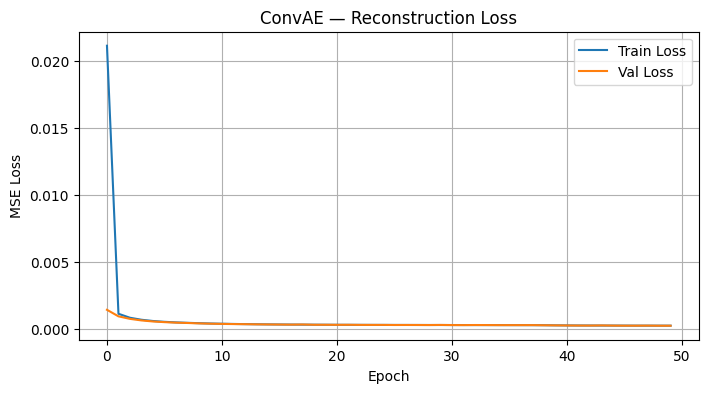

In [ ]:
def plot_loss(train_losses, val_losses,model):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses,  label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(0.3)
    plt.legend()
    plt.title(f'{model.__class__.__name__} — Reconstruction Loss')
    plt.show()

plot_loss(train_loss,val_loss,conv_ae)

In [ ]:
def show_reconstructions(model, loader, n=8):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:n].to(device)

    with torch.no_grad():
        recon, _ = model(images)

        fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

        for i in range(n):
            axes[0,i].imshow(images[i].squeeze(), cmap='gray')
            axes[1,i].imshow(recon[i].squeeze(), cmap='gray')
            axes[0,i].set_xticks([])
            axes[0,i].set_yticks([])
            axes[1,i].set_xticks([])
            axes[1,i].set_yticks([])

        axes[0,0].set_ylabel('Original', fontsize=12)
        axes[1,0].set_ylabel('Reconstructed', fontsize=12)

        fig.subplots_adjust(left=0.15)
        plt.suptitle(f'{model.__class__.__name__} Reconstructions')

        plt.show()

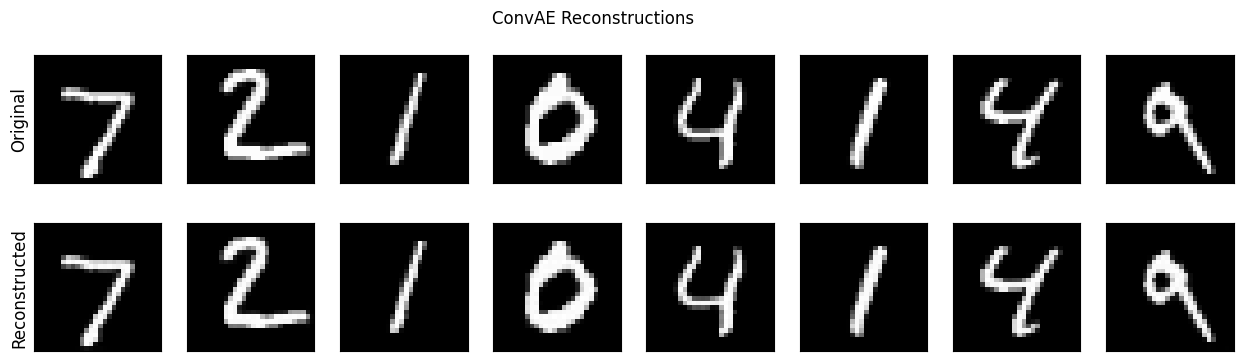

In [ ]:
show_reconstructions(conv_ae, test_loader)

In [ ]:
def compute_test_mse(model, loader, noise_fn=None):
    model.eval()
    criterion = nn.MSELoss()
    total = 0.0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            inp  = noise_fn(imgs) if noise_fn else imgs
            xhat, _ = model(inp)
            total += criterion(xhat, imgs).item()
    return total / len(loader)

mse=compute_test_mse(conv_ae,test_loader)
print(f"Convolutional AE — Test MSE (reconstruction only): {mse:.5f}")

Convolutional AE — Test MSE (reconstruction only): 0.00021


## 2: Denoising Autoencoder (DAE)
A Denoising Autoencoder is trained to reconstruct a clean input from a corrupted version. This forces the model to learn robust, meaningful features rather than just memorising the identity function.

**Same architecture** as Conv AE — only the training differs.  
**Loss:** MSE between reconstruction and the **original clean** image.

Gaussian noise (σ = 0.3), clamped to [0, 1].

### Noise Function

In [ ]:
def gaussian_noise(x, std=0.3):
    """Add Gaussian noise; clamp to valid range."""
    noise = torch.randn_like(x) * std
    return (x + noise).clamp(-1.0, 1.0)

### DAE Training

In [ ]:
print("Training Denoising AE...")
denoise_ae = ConvAE().to(device)
train_loss,val_loss = train_model(denoise_ae, train_loader, val_loader, epochs=50,
                          noise_fn=gaussian_noise)

Training Denoising AE...
  Epoch  2/50 | Train: 0.0060 | Val: 0.0058
  Epoch  4/50 | Train: 0.0055 | Val: 0.0055
  Epoch  6/50 | Train: 0.0053 | Val: 0.0054
  Epoch  8/50 | Train: 0.0052 | Val: 0.0053
  Epoch 10/50 | Train: 0.0052 | Val: 0.0052
  Epoch 12/50 | Train: 0.0051 | Val: 0.0051
  Epoch 14/50 | Train: 0.0051 | Val: 0.0051
  Epoch 16/50 | Train: 0.0051 | Val: 0.0051
  Epoch 18/50 | Train: 0.0051 | Val: 0.0051
  Epoch 20/50 | Train: 0.0050 | Val: 0.0051
  Epoch 22/50 | Train: 0.0050 | Val: 0.0050
  Epoch 24/50 | Train: 0.0050 | Val: 0.0050
  Epoch 26/50 | Train: 0.0050 | Val: 0.0050
  Epoch 28/50 | Train: 0.0050 | Val: 0.0050
  Epoch 30/50 | Train: 0.0050 | Val: 0.0050
  Epoch 32/50 | Train: 0.0050 | Val: 0.0049
  Epoch 34/50 | Train: 0.0049 | Val: 0.0049
  Epoch 36/50 | Train: 0.0049 | Val: 0.0049
  Epoch 38/50 | Train: 0.0049 | Val: 0.0049
  Epoch 40/50 | Train: 0.0049 | Val: 0.0049
  Epoch 42/50 | Train: 0.0049 | Val: 0.0049
  Epoch 44/50 | Train: 0.0049 | Val: 0.0049
  Epoch

###Visualisation: Original · Noisy · Denoised

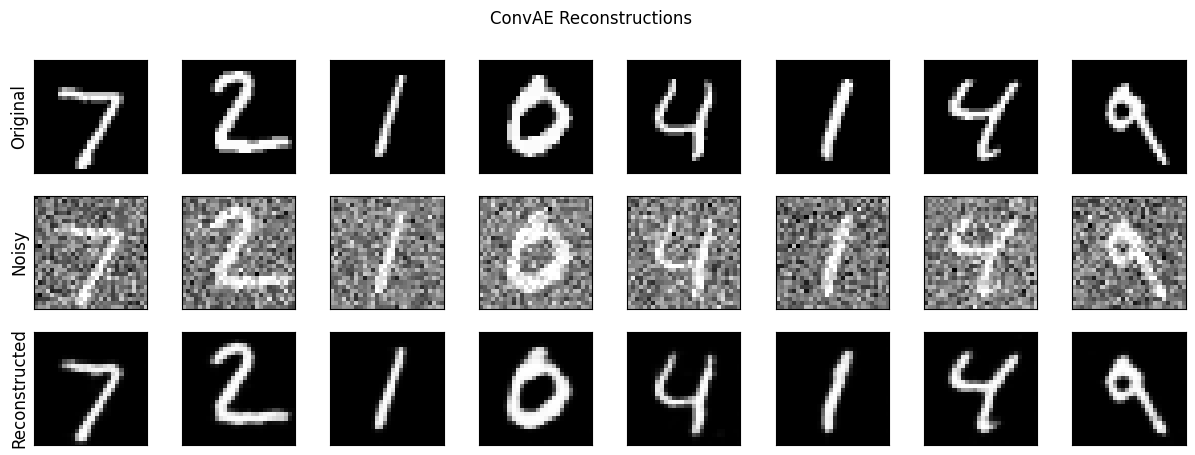

In [ ]:
denoise_ae.eval()
imgs,_=next(iter(test_loader))
imgs=imgs[:8].to(device)
with torch.no_grad():
    noisy_imgs=gaussian_noise(imgs)
    recon,_=denoise_ae(noisy_imgs)
    imgs=imgs.cpu()
    noisy_imgs=noisy_imgs.cpu()
    recon=recon.cpu()

    fig,axes=plt.subplots(3,8,figsize=(15,5))
    for i in range(8):
        axes[0,i].imshow(imgs[i].squeeze(),cmap='gray')
        axes[1,i].imshow(noisy_imgs[i].squeeze(),cmap='gray')
        axes[2,i].imshow(recon[i].squeeze(),cmap='gray')
        axes[0,i].set_xticks([])
        axes[0,i].set_yticks([])
        axes[1,i].set_xticks([])
        axes[1,i].set_yticks([])
        axes[2,i].set_xticks([])
        axes[2,i].set_yticks([])

    axes[0,0].set_ylabel('Original',fontsize=12)
    axes[1,0].set_ylabel('Noisy',fontsize=12)
    axes[2,0].set_ylabel('Reconstructed',fontsize=12)
    plt.suptitle(f'{denoise_ae.__class__.__name__} Reconstructions')
    plt.show()

Loss Curve

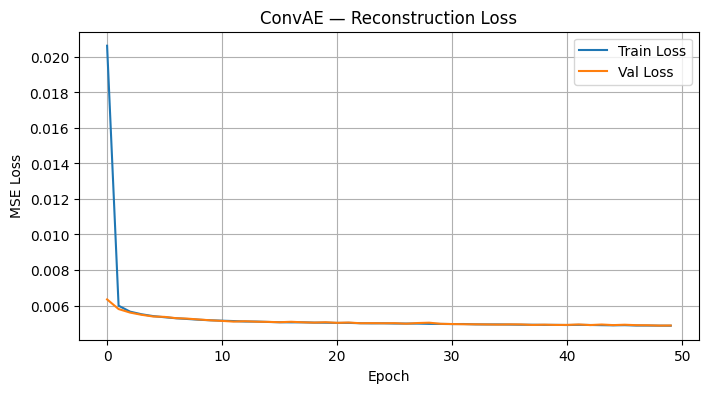

In [ ]:
plot_loss(train_loss,val_loss,denoise_ae)

MSE LOSS

In [ ]:
print(f"Denoising AE — Test MSE:{compute_test_mse(denoise_ae, test_loader, noise_fn=gaussian_noise)}")

Denoising AE — Test MSE:0.0048326685384010816


##3: Variational AutoEncoder
Instead of encoding x into a single point z, the encoder outputs a *distribution* N(μ, σ²) over z. We sample z from that distribution using the reparameterisation trick, then decode.



**Why?** Forces the latent space to be smooth and continuous — every point in it decodes to something meaningful, so we can *generate* new images by sampling z ~ N(0, I).

**Loss:** Reconstruction (BCE) + KL divergence

```
Loss = BCE(x̂, x)  +  β · KL( N(μ,σ²) ‖ N(0,I) )
                         └── pushes encoder toward prior
```



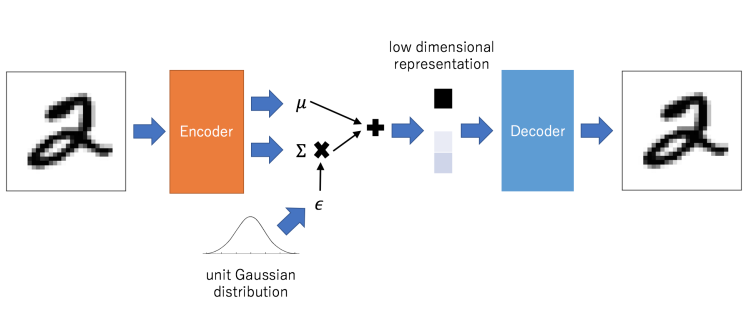

### VAE Architecture

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(784, 256), nn.ReLU(),
                    nn.Linear(256, 128), nn.ReLU(),
                    )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid()
             )
        self.fc_mu     = nn.Linear(128, latent_dim)  # → mean μ
        self.fc_logvar = nn.Linear(128, latent_dim)  # → log variance log σ²

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        # z = μ + σ·ε,  ε ~ N(0,I)
        # This keeps the operation differentiable — randomness is in ε, not μ/σ
        std = torch.exp(0.5 * logvar)   # σ = exp(0.5 · log σ²)
        eps = torch.randn_like(std)     # ε ~ N(0,I)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterise(mu, logvar)
        return self.decode(z), [ mu, logvar]

    def sample(self, n=16):
        """Generate new images: sample z ~ N(0,I), then decode."""
        z = torch.randn(n, self.latent_dim).to(device)
        with torch.no_grad():
            return self.decode(z)

vae = VAE(latent_dim=32).to(device)
summary(vae, (1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 128]                  --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 256]                  200,960
│    └─ReLU: 2-3                         [1, 256]                  --
│    └─Linear: 2-4                       [1, 128]                  32,896
│    └─ReLU: 2-5                         [1, 128]                  --
├─Linear: 1-2                            [1, 32]                   4,128
├─Linear: 1-3                            [1, 32]                   4,128
├─Sequential: 1-4                        [1, 784]                  --
│    └─Linear: 2-6                       [1, 128]                  4,224
│    └─ReLU: 2-7                         [1, 128]                  --
│    └─Linear: 2-8                       [1, 256]                  

### VAE Training

In [ ]:
import torch.nn.functional as F
# ── VAE Loss ──
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    """VAE loss = Reconstruction loss + β · KL divergence"""
    recon = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
    # KL divergence: closed form for Gaussian
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    return recon + beta * kl, recon, kl


In [ ]:
def train_vae(model, train_loader, val_loader, epochs=30, lr=1e-3, beta=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = {'train': [], 'val': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        t_total = t_recon = t_kl = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            xhat,mu_logvar = model(imgs)
            mu,logvar = mu_logvar
            loss, recon, kl  = vae_loss(xhat, imgs, mu, logvar, beta)

            loss.backward()
            optimizer.step()
            t_total += loss.item()
            t_recon += recon.item()
            t_kl    += kl.item()

        n = len(train_loader)
        history['train'].append(t_total / n)
        history['recon'].append(t_recon / n)
        history['kl'].append(t_kl / n)

        # ── Validate ──
        model.eval()
        v_total = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                xhat,mu_logvar = model(imgs)
                mu,logvar = mu_logvar
                loss, _, _ = vae_loss(xhat, imgs, mu, logvar, beta)
                v_total += loss.item()
        history['val'].append(v_total / len(val_loader))

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{epochs} | "
                  f"Train: {history['train'][-1]:.1f} "
                  f"(recon={history['recon'][-1]:.1f}) | "
                  f"Val: {history['val'][-1]:.1f}")

    return history

print("Training VAE...")
vae_history = train_vae(vae, train_loader, val_loader, epochs=50, beta=1.0)

Training VAE...
  Epoch  5/50 | Train: 112.3 (recon=94.5) | Val: 111.7
  Epoch 10/50 | Train: 106.6 (recon=87.9) | Val: 107.2
  Epoch 15/50 | Train: 104.6 (recon=85.5) | Val: 105.3
  Epoch 20/50 | Train: 103.4 (recon=84.2) | Val: 104.4
  Epoch 25/50 | Train: 102.6 (recon=83.3) | Val: 103.8
  Epoch 30/50 | Train: 102.1 (recon=82.7) | Val: 103.6
  Epoch 35/50 | Train: 101.6 (recon=82.1) | Val: 103.2
  Epoch 40/50 | Train: 101.2 (recon=81.7) | Val: 102.9
  Epoch 45/50 | Train: 100.9 (recon=81.3) | Val: 102.7
  Epoch 50/50 | Train: 100.7 (recon=81.0) | Val: 102.5


Note: VAE optimises BCE+KL jointly, so MSE is higher than pure reconstruction AEs. The key strength is generation, not reconstruction quality.

###Loss curve

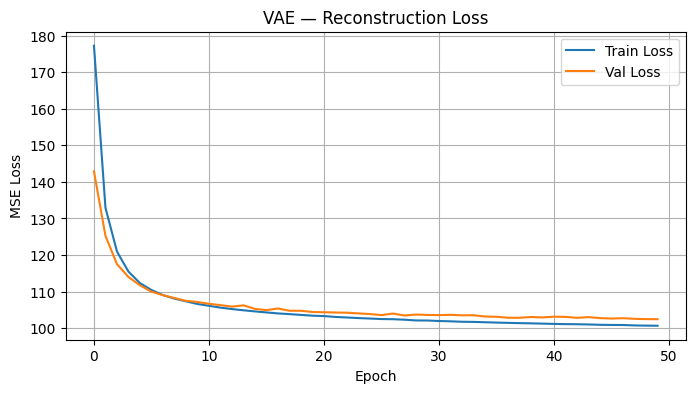

In [ ]:
plot_loss(vae_history['train'],vae_history['val'],vae)

### Visualisation: Original vs Reconstructed

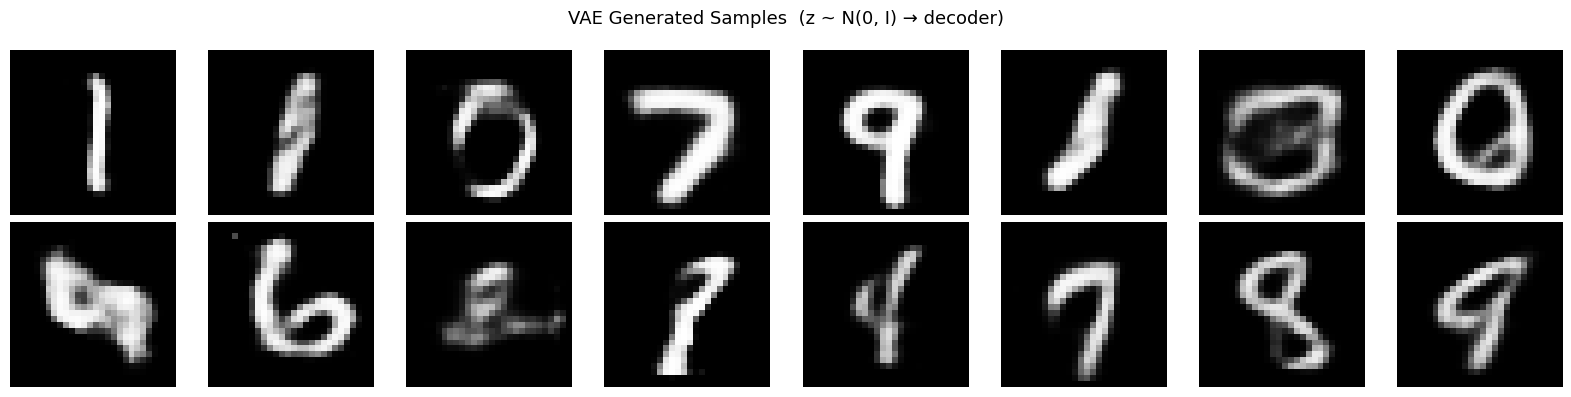

In [ ]:
# Generate 16 new images — this is what separates VAE from all other AEs
vae.eval()
generated = vae.sample(n=16)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle('VAE Generated Samples  (z ~ N(0, I) → decoder)', fontsize=13)
plt.tight_layout()
plt.show()

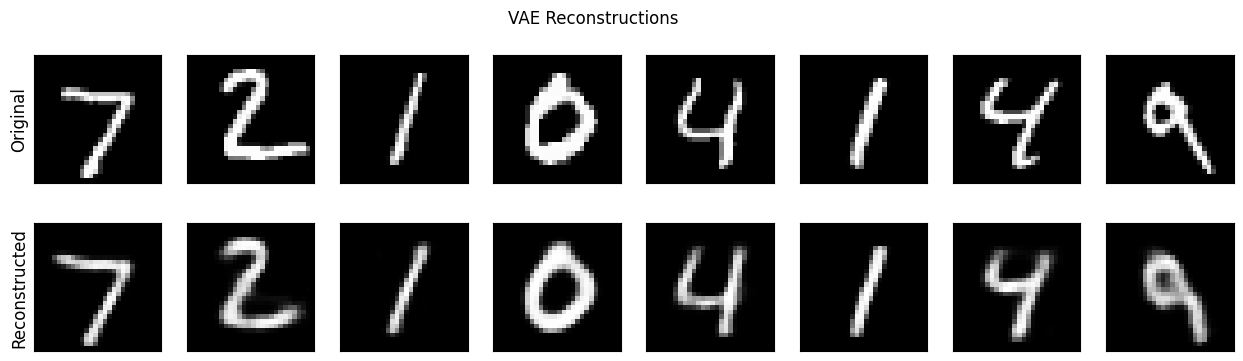

In [ ]:
show_reconstructions(vae, test_loader)

###MSE loss

In [ ]:
vae_mse = compute_test_mse(vae, test_loader)
print(f"VAE — Test MSE (reconstruction only): {vae_mse:.5f}")

VAE — Test MSE (reconstruction only): 0.01422


### Dimentinalty Reduction and latent space visualisation

2D VAE for Latent space visualisation...
  Epoch  5/10 | Train: 149.8 (recon=143.7) | Val: 149.0
  Epoch 10/10 | Train: 144.4 (recon=138.0) | Val: 144.8


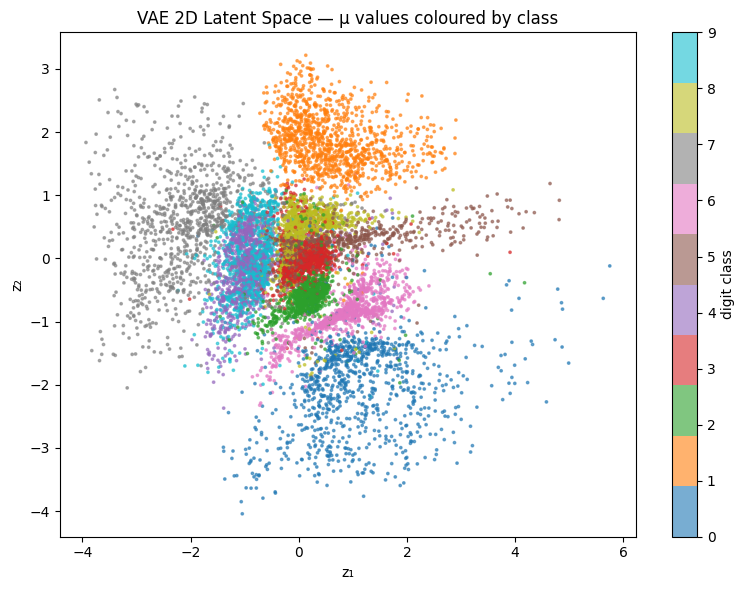

In [ ]:
vae_2d = VAE(latent_dim=2).to(device)
print("2D VAE for Latent space visualisation...")
train_vae(vae_2d, train_loader, val_loader, epochs=10, beta=1.0)

# Plot latent codes coloured by digit class
vae_2d.eval()
zs, labs = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        mu, _ = vae_2d.encode(imgs.to(device))   # use μ as the point
        zs.append(mu.cpu())
        labs.extend(labels.tolist())

zs = torch.cat(zs).numpy()

plt.figure(figsize=(8, 6))
sc = plt.scatter(zs[:, 0], zs[:, 1], c=labs, cmap='tab10', s=3, alpha=0.6)
plt.colorbar(sc, ticks=range(10), label='digit class')
plt.title('VAE 2D Latent Space — μ values coloured by class')
plt.xlabel('z₁'); plt.ylabel('z₂')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.decomposition import PCA
# Extract images and labels from the test dataset
images = []
labels = []
for img, label in test_dataset:
    images.append(img.numpy())
    labels.append(label)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Flatten the images: (num_samples, 1, 28, 28) -> (num_samples, 784)
flattened_images = images.reshape(images.shape[0], -1)

print(f"Shape of flattened images: {flattened_images.shape}")
print(f"Shape of labels: {labels.shape}")


Shape of flattened images: (10000, 784)
Shape of labels: (10000,)


Shape of PCA-transformed data: (10000, 2)


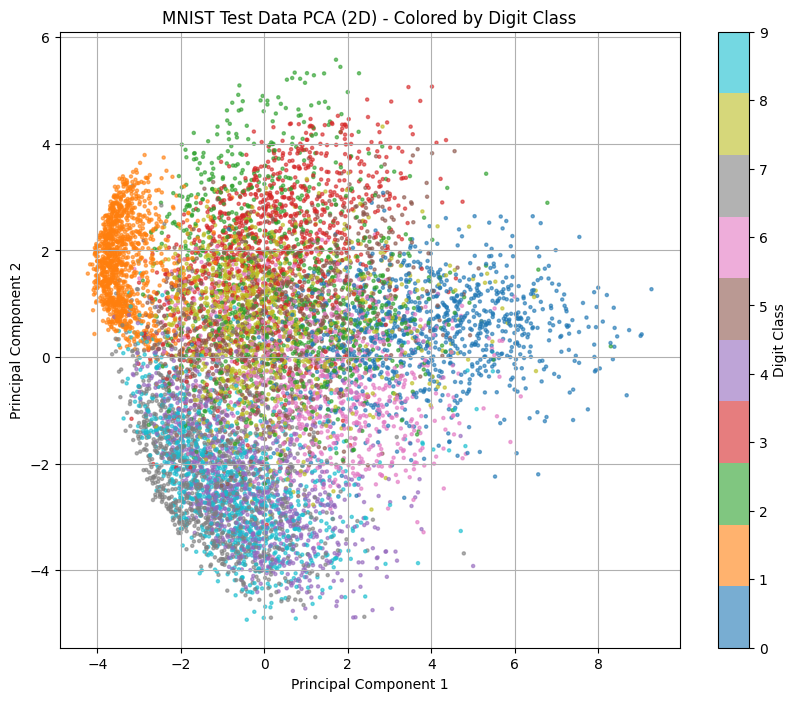

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(flattened_images)

print(f"Shape of PCA-transformed data: {pca_result.shape}")
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title('MNIST Test Data PCA (2D) - Colored by Digit Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()
